In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
df = pd.read_csv('/content/для регрессии.csv')
df.head(5)

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


Head() используется для того, чтобы убедиться в том, что датасет загрузился, выводит первые 5 строк.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


df.info() показывает, сколько строк и столбцов в датасете, тип данных каждого.

Уникальный студенческий идентификационный номер

Основные демографические данные, такие как возраст, пол и специальность.

Подробная информация об учебных привычках студента, включая количество часов, затрачиваемых на учебу ежедневно, и посещаемость занятий.

Информация, связанная с образом жизни, такая как продолжительность и качество сна.

Доступ к таким ресурсам, как доступ в интернет.

Показатели академической среды, такие как рейтинг материально-технической базы.

Уровень сложности пройденного экзамена

Итоговая оценка за экзамен, варьирующаяся от 0 до 100.

In [ ]:
df.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


describe() выводит описание датасета, количество строк, среднее значение, минимальное и максимальное значение и тд. В этом окне только числовые признаки.

In [ ]:
df.describe(include=[object])

,gender,course,internet_access,sleep_quality,study_method,facility_rating,exam_difficulty
count,20000,20000,20000,20000,20000,20000,20000
unique,3,7,2,3,5,3,3
top,other,bca,yes,average,self-study,medium,moderate
freq,6726,2902,16988,6694,4079,6760,9878


describe(include=[object]) также выводит описание датасета, количество значений в столбце, количество уникальных значений, самое часто используемое и частота. В этом окне уже только объекты.

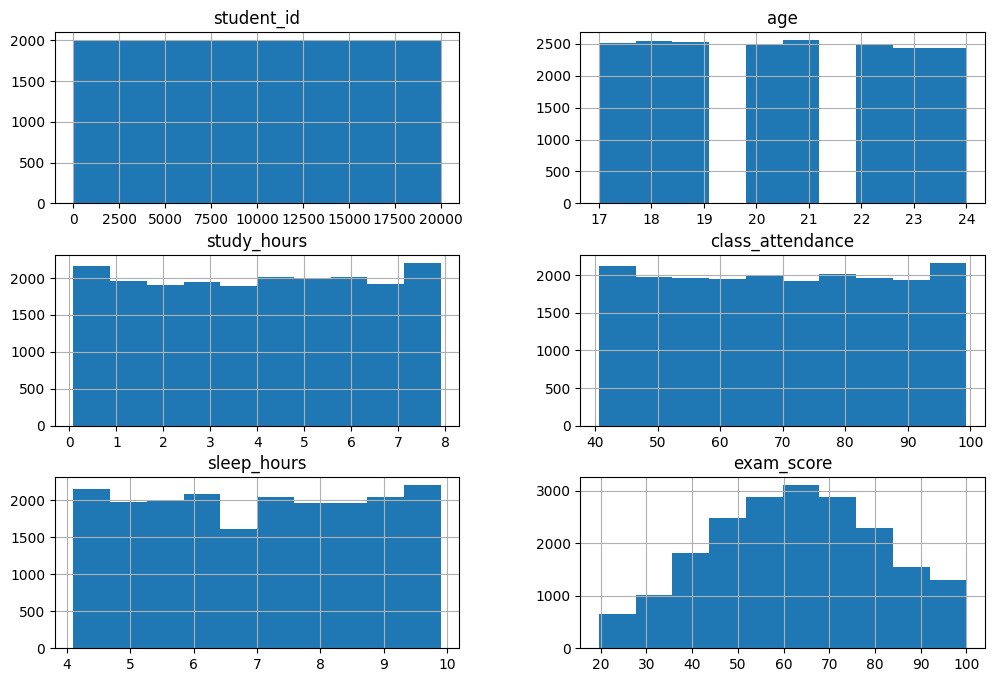

In [ ]:
df.hist(df.columns, figsize=(12,8))
plt.show()

Построила графики распределений - hist, чтобы посмотреть значения и частоту. В этом датасете распределение равномерное по всем столбцам.

In [ ]:
df.isnull().sum().max()

0

df.isnull().sum().max() проверяю наличие пустых значений (0 - их нет, удалять не нужно)

In [ ]:
df = df.drop('student_id', axis=1)
df.head(2)

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8


Удалила student_id - столбец не нужен для модели

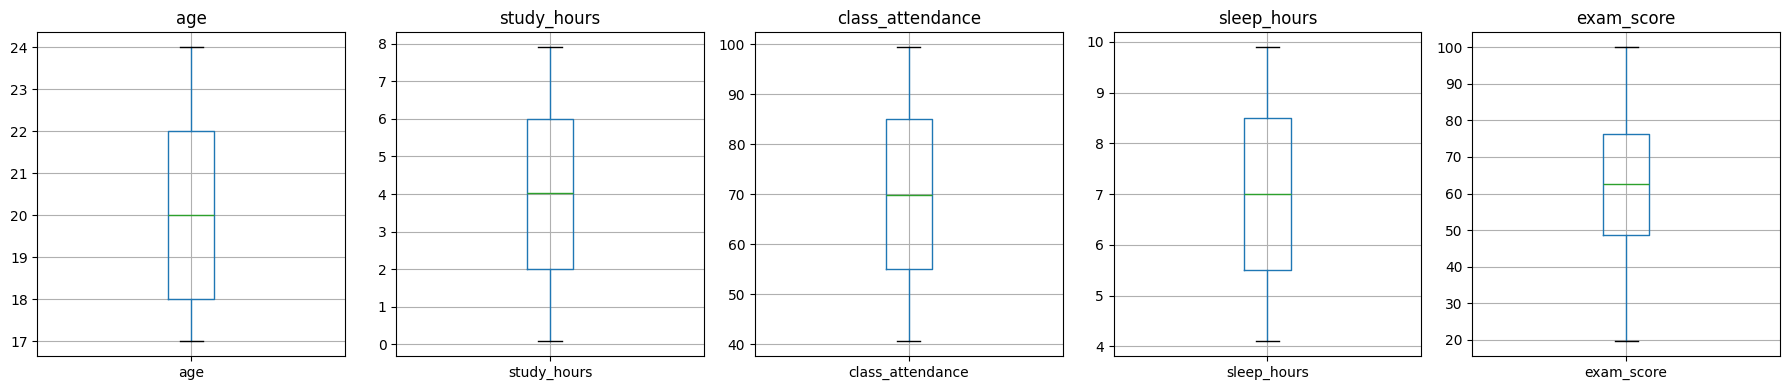

In [ ]:
numeric_cols = ['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score']
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 4))
for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

Построила ящики с усами boxplot для того, чтобы посмотреть есть ли выбросы. В данном случае выбросов нет ни в одном признаке, удалять выбросы не нужно.

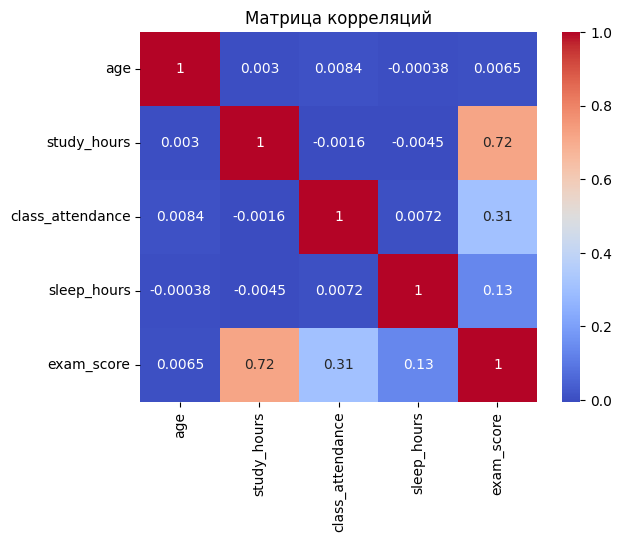

In [ ]:
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

Построила матрицу корреляции, показывает какие признаки больше всего влияют на итоговый результат. Здесь видно, что наиболее значимая связь между часами учёбы и экзаменационным баллом. Остальные показатели слабо или не связаны с результатами. Продолжительность сна, например, слабо коррелирует (0.13), это говорит о незначительном влиянии этого фактора в данной выборке.

In [ ]:
from sklearn.preprocessing import StandardScaler
numeric_cols = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df.head(2)

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,-1.520442,male,diploma,-0.531832,1.324086,yes,0.225999,poor,coaching,low,hard,58.9
1,1.106067,other,bca,-0.276227,-0.301899,yes,-1.390586,average,online videos,medium,moderate,54.8


Провожу стандартизацию методом StandardScaler(), чтобы привести все числовые данные к нулевому среднему и единичному стандартному отклонению.

In [ ]:
categorical_cols = ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df.head(1)

,age,study_hours,class_attendance,sleep_hours,exam_score,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,...,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium,exam_difficulty_hard,exam_difficulty_moderate
0,-1.520442,-0.531832,1.324086,0.225999,58.9,True,False,False,False,False,...,False,True,False,False,False,False,True,False,True,False


Провожу категорирование методом pd.get_dummies(), чтобы перевести текстовые данные в true/false, понятные машине.

In [ ]:
x = df.drop('exam_score', axis=1)
y = df['exam_score']
x.head(2)

,age,study_hours,class_attendance,sleep_hours,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,...,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium,exam_difficulty_hard,exam_difficulty_moderate
0,-1.520442,-0.531832,1.324086,0.225999,True,False,False,False,False,False,...,False,True,False,False,False,False,True,False,True,False
1,1.106067,-0.276227,-0.301899,-1.390586,False,True,False,False,False,False,...,False,False,False,False,True,False,False,True,False,True


Поделила на x и y для обучения модели, x - все признаки, y - искомый аргумент (баллы за экзамен).

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)
y_train.shape, y_test.shape

((16000,), (4000,))

Поделила на тестовые и тренировочные данные

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

Создала модель LinearRegression

In [ ]:
y_train_predicted = model.predict(x_train)
y_test_predicted = model.predict(x_test)

train_MSE1 = mean_squared_error(y_train, y_train_predicted)
test_MSE1 = mean_squared_error(y_test, y_test_predicted)
train_MAE1 = mean_absolute_error(y_train, y_train_predicted)
test_MAE1 = mean_absolute_error(y_test, y_test_predicted)
train_r1 = r2_score(y_train, y_train_predicted)
test_r1 = r2_score(y_test, y_test_predicted)
print(f'Результаты LinearRegression: {train_MSE1}, \n{test_MSE1}, \n{train_MAE1}, \n{test_MAE1}, \n{train_r1}, \n{test_r1}')

Результаты LinearRegression: 96.38675605708391, 
93.2311599605805, 
7.879178958194885, 
7.746670645428663, 
0.7301370238512653, 
0.7401527601962383


MSE и MAE показывают среднюю ошибку предсказания. Чем меньше, тем лучше. R2 показывает, какая доля дисперсии целевой переменной объяснена моделью. Должна стремиться к 1.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn import neighbors
knn = neighbors.KNeighborsRegressor()
params = {'n_neighbors': [5,7, 2, 3, 4, 6, 8, 9, 10], 'metric':['euclidean','cityblock']}
grid = GridSearchCV(estimator = knn, param_grid = params)
grid.fit(x_train, y_train)
print(grid.best_score_)
print(grid.best_estimator_.n_neighbors)
print(grid.best_estimator_.metric)

0.6461650153068137
10
euclidean


Подобрала гиперпараметры для метода соседей

In [ ]:
neighbors = neighbors.KNeighborsRegressor(n_neighbors = 10, metric='euclidean')
neighbors.fit(x_train, y_train)

KNeighborsRegressor(metric='euclidean', n_neighbors=10)

Создала модель KNeighborsRegressor метод ближайших соседей

In [ ]:
y_train_predicted2 = neighbors.predict(x_train)
y_test_predicted2 = neighbors.predict(x_test)

train_MSE2 = mean_squared_error(y_train, y_train_predicted2)
test_MSE2 = mean_squared_error(y_test, y_test_predicted2)
train_MAE2 = mean_absolute_error(y_train, y_train_predicted2)
test_MAE2 = mean_absolute_error(y_test, y_test_predicted2)
train_r2 = r2_score(y_train, y_train_predicted2)
test_r2 = r2_score(y_test, y_test_predicted2)
print(f'Результаты KNeighborsRegressor: {train_MSE2}, \n{test_MSE2}, \n{train_MAE2}, \n{test_MAE2}, \n{train_r2}, \n{test_r2}')

Результаты KNeighborsRegressor: 102.80293816244875, 
120.08540057003, 
8.1718404625, 
8.857021200000002, 
0.7121730413572331, 
0.6653065360117281


In [ ]:
from sklearn.svm import SVR
svr = SVR()
svr.fit(x_train, y_train)

SVR()

Создала модель SVR

In [ ]:
y_train_predicted3 = svr.predict(x_train)
y_test_predicted3 = svr.predict(x_test)

train_MSE3 = mean_squared_error(y_train, y_train_predicted3)
test_MSE3 = mean_squared_error(y_test, y_test_predicted3)
train_MAE3 = mean_absolute_error(y_train, y_train_predicted3)
test_MAE3 = mean_absolute_error(y_test, y_test_predicted3)
train_r3 = r2_score(y_train, y_train_predicted3)
test_r3 = r2_score(y_test, y_test_predicted3)
print(f'Результаты SVR: {train_MSE3}, \n{test_MSE3}, \n{train_MAE3}, \n{test_MAE3}, \n{train_r3}, \n{test_r3}')

Результаты SVR: 96.27777243089487, 
98.14505675955056, 
7.809534503111226, 
7.966709438173497, 
0.7304421554577014, 
0.7264570974968491


In [ ]:
data = pd.DataFrame({
    'Метрики': ['train_MSE', 'test_MSE', 'train_MAE', 'test_MAE', 'train_r2', 'test_r2'],
    'линейная регрессия': [train_MSE1, test_MSE1, train_MAE1, test_MAE1, train_r1, test_r1],
    'метод ближайших соседей': [train_MSE2, test_MSE2, train_MAE2, test_MAE2, train_r2, test_r2],
    'метод опорных векторов': [train_MSE3, test_MSE3, train_MAE3, test_MAE3, train_r3, test_r3],})
dfs = pd.DataFrame(data)
dfs.head(10)

,Метрики,линейная регрессия,метод ближайших соседей,метод опорных векторов
0,train_MSE,96.386756,102.802938,96.277772
1,test_MSE,93.231160,120.085401,98.145057
2,train_MAE,7.879179,8.171840,7.809535
3,test_MAE,7.746671,8.857021,7.966709
4,train_r2,0.730137,0.712173,0.730442
5,test_r2,0.740153,0.665307,0.726457


Вывод: Линейная регрессия показывает наилучшее обобщение: наименьшая ошибка на тесте и самый высокий R2 на тесте. При этом метрики на обучающей и тестовой выборках почти совпадают, переобучения нет.